In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset_path = "/kaggle/input/datasets/jhonbadha/brain-tumor/Brain_Cancer"

labels = []
images = []

for label in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, label)
    
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        labels.append(label)
        images.append(img_path)

df = pd.DataFrame({
    "image_path": images,
    "label": labels
})

print(df.head())

                                          image_path        label
0  /kaggle/input/datasets/jhonbadha/brain-tumor/B...  brain_tumor
1  /kaggle/input/datasets/jhonbadha/brain-tumor/B...  brain_tumor
2  /kaggle/input/datasets/jhonbadha/brain-tumor/B...  brain_tumor
3  /kaggle/input/datasets/jhonbadha/brain-tumor/B...  brain_tumor
4  /kaggle/input/datasets/jhonbadha/brain-tumor/B...  brain_tumor


In [7]:
print("Dataset Shape:", df.shape)
print("Class Labels:", df['label'].unique())

Dataset Shape: (6056, 2)
Class Labels: ['brain_tumor' 'brain_glioma' 'brain_menin']


label
brain_tumor     2048
brain_glioma    2004
brain_menin     2004
Name: count, dtype: int64


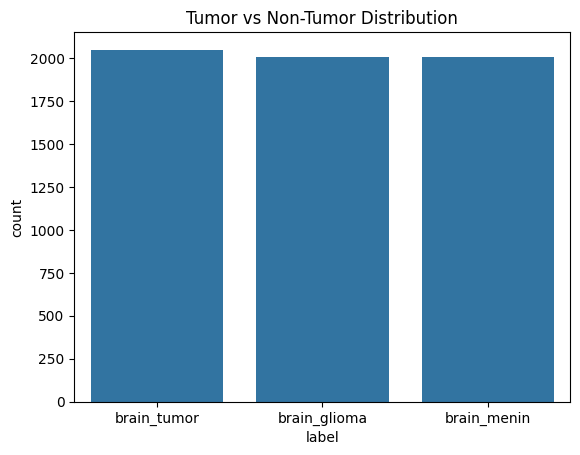

In [8]:
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title("Tumor vs Non-Tumor Distribution")
plt.show()

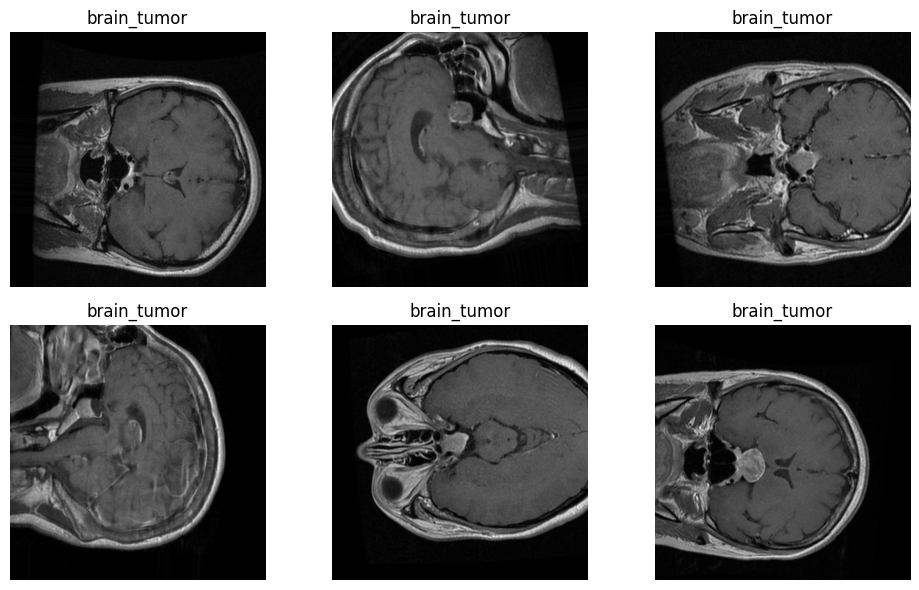

In [9]:
plt.figure(figsize=(10,6))

for i in range(6):
    img = cv2.imread(df['image_path'][i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(df['label'][i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
sizes = []

for path in df['image_path']:
    img = cv2.imread(path)
    sizes.append(img.shape)

sizes = pd.DataFrame(sizes, columns=['Height','Width','Channels'])
print(sizes.describe())

       Height   Width  Channels
count  6056.0  6056.0    6056.0
mean    512.0   512.0       3.0
std       0.0     0.0       0.0
min     512.0   512.0       3.0
25%     512.0   512.0       3.0
50%     512.0   512.0       3.0
75%     512.0   512.0       3.0
max     512.0   512.0       3.0


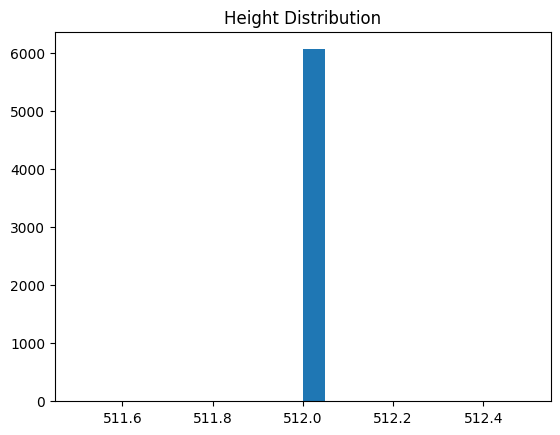

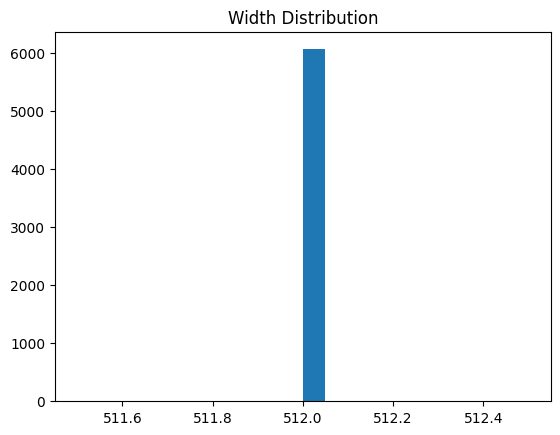

In [11]:
plt.hist(sizes['Height'], bins=20)
plt.title("Height Distribution")
plt.show()

plt.hist(sizes['Width'], bins=20)
plt.title("Width Distribution")
plt.show()

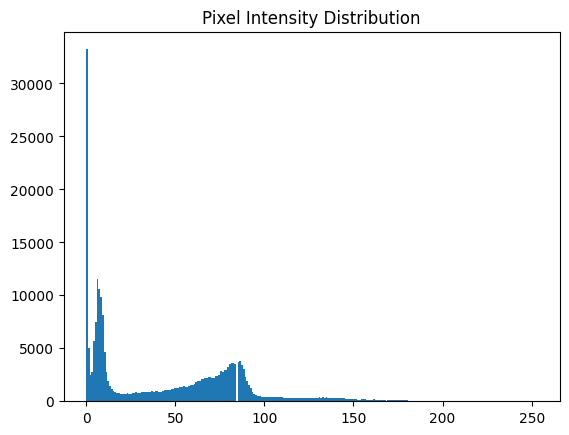

In [12]:
img = cv2.imread(df['image_path'][0],0)

plt.hist(img.ravel(), bins=256)
plt.title("Pixel Intensity Distribution")
plt.show()

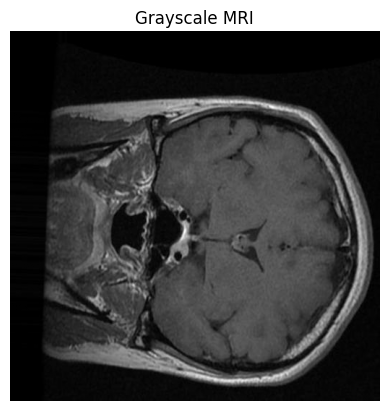

In [13]:
img = cv2.imread(df['image_path'][0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale MRI")
plt.axis("off")
plt.show()

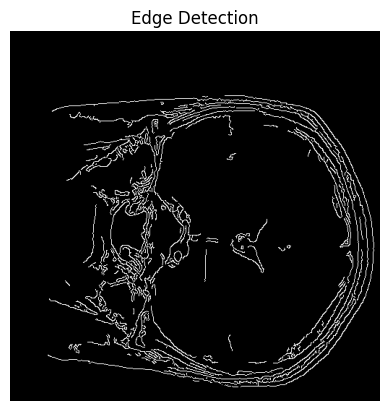

In [14]:
edges = cv2.Canny(gray,100,200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis("off")
plt.show()

In [15]:
print("Min pixel:", img.min())
print("Max pixel:", img.max())
img = img / 255.0

Min pixel: 0
Max pixel: 253


In [16]:
print("Duplicate images:", df.duplicated().sum())

Duplicate images: 0
